In [1]:
try:
    import ydf
except:
    %pip install -q -U ydf
    import ydf

print(f"ydf version: {ydf.__version__}")


[notice] A new release of pip is available: 25.0.1 -> 26.1.2
[notice] To update, run: pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.


/usr/local/lib/python3.12/site-packages/jax/_src/cloud_tpu_init.py:88: UserWarning: Transparent hugepages are not enabled. TPU runtime startup and shutdown time should be significantly improved on TPU v5e and newer. If not already set, you may need to enable transparent hugepages in your VM image (sudo sh -c "echo always > /sys/kernel/mm/transparent_hugepage/enabled")
  warnings.warn(


ydf version: 0.16.1


In [2]:
## -- System dependencies --
import sys, os, gc
import torch

## -- Device-Agnostic for GPU --
if torch.cuda.is_available():
    print(f"ℹ️ Device GPU: {torch.cuda.get_device_name(0)}")
    print(f"ℹ️ No. of CPU: {os.cpu_count()} cores")
    # get_ipython().run_line_magic('load_ext', 'cudf.pandas')
    # get_ipython().run_line_magic('load_ext', 'cuml.accel')
    # from cuml.preprocessing import TargetEncoder as cuTE
else:
    print(f"ℹ️ Device: CPU {os.cpu_count()} cores")

ℹ️ Device: CPU 224 cores


In [3]:
## -- Data Manipulation --
import numpy as np, pandas as pd, random

## -- Visualization --
from IPython.display import display, Image
import matplotlib.pyplot as plt
import seaborn as sns

## -- Functional Tools --
import itertools
from time import time, sleep
from tqdm.notebook import tqdm

## -- Machine Learning --
import sklearn
from sklearn.calibration import CalibrationDisplay
from sklearn.utils.class_weight import compute_class_weight
from sklearn.model_selection import KFold, StratifiedKFold, train_test_split
from sklearn.preprocessing import StandardScaler, TargetEncoder, label_binarize
from sklearn.metrics import balanced_accuracy_score, log_loss, RocCurveDisplay

from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.compose import ColumnTransformer, make_column_transformer

import warnings
warnings.simplefilter('ignore')
warnings.filterwarnings('ignore')

In [4]:
## -- Global Settings --
sklearn.set_config(transform_output="pandas")

# pd.options.mode.copy_on_write = True
pd.set_option('display.max_columns', 1000)
sns.set_style("whitegrid")
# plt.style.use('ggplot')

PALETTE = ['#3A86FF', '#F94144', '#FFBE0B', '#73D2DE', '#FBB13C']
sns.set_palette(PALETTE)

cmap = sns.diverging_palette(0, 230, 90, 60, as_cmap=True)

## -- Set Global Seed --
CFG = {
    'FOLDS':   5,
    'SEED':    42,
    'GREEN':  '\033[32m',
    'YELLOW': '\033[33m',
    'RESET':  '\033[0m'
}

print(f"CLASSIC {CFG['GREEN']} GREEN {CFG['RESET']} {CFG['YELLOW']} YELLOW {CFG['RESET']}")

CLASSIC  GREEN   YELLOW 


In [5]:
## -- ⚠️ IMPORTANT: SELECT PLATFORM ⚠️ --
PLATFORM = 'kaggle' # -> 'colab' 'kaggle'

if PLATFORM == 'kaggle':
    PATH = '/kaggle/input/competitions/playground-series-s6e7/'
    submit = pd.read_csv(PATH+'sample_submission.csv')
    train = pd.read_csv(PATH+'train.csv')
    test = pd.read_csv(PATH+'test.csv')

    ORIG_PATH = '/kaggle/input/datasets/ziya07/college-student-health-behavior-dataset/'
    orig = pd.read_csv(ORIG_PATH+'student_health_dataset_50k.csv')
elif PLATFORM == 'colab':
    from google.colab import drive
    drive.mount('/content/drive')

    PATH = '/content/drive/MyDrive/-- shared_notebooks --/Ps6e7 | Student Health/_student_health_data/'
    submit = pd.read_csv(PATH+'sample_submission.csv')
    train = pd.read_csv(PATH+'train.csv')
    test = pd.read_csv(PATH+'test.csv')
    orig = pd.read_csv(PATH+'student_health_dataset_50k.csv')

## =================================================================================

ID = 'id'
TARGET  = 'health_condition'
OBJECTS = train.select_dtypes(include=['object', 'category']).columns.tolist()

CATS = [c for c in OBJECTS if c not in [TARGET, ID]]
NUMS = [c for c in train.columns if c not in CATS+[TARGET, ID]]
BASE = NUMS + CATS

NUM_CLASSES = train[TARGET].nunique()

# {c: i for i, c in enumerate(train[TARGET].unique())}
mapping   = {'fit': 0, 'at-risk': 1, 'unhealthy': 2}
r_mapping = {v: k for k, v in mapping.items()}

train[TARGET] = train[TARGET].map(mapping)
orig[TARGET]  = orig[TARGET].map(mapping)

for (name, df) in {'Train': train, 'Test': test, 'Orig': orig}.items():
    print(f"{name} shape: {df.shape}")

print(f"\nTotal Numerical: {len(NUMS)}")
print(f"Total Categorical: {len(CATS)}")
print(f"Total base features: {len(BASE)}")

Train shape: (690088, 15)
Test shape: (295753, 14)
Orig shape: (50000, 16)

Total Numerical: 7
Total Categorical: 6
Total base features: 13


In [6]:
display(train.head())
train.info()

,id,health_condition,sleep_duration,heart_rate,bmi,calorie_expenditure,step_count,exercise_duration,water_intake,diet_type,stress_level,sleep_quality,physical_activity_level,smoking_alcohol,gender
0,0,2,5.22,70.6,25.66,2174.0,1326.0,19.8,1.86,veg,high,average,sedentary,yes,female
1,1,1,5.53,71.3,25.84,1966.0,9891.0,49.9,1.26,non-veg,low,average,moderate,yes,other
2,2,2,5.29,75.4,24.54,2688.0,14216.0,38.1,1.60,veg,high,poor,active,yes,male
3,3,2,4.70,77.2,23.13,2630.0,7174.0,59.9,2.02,veg,high,average,active,occasional,female
4,4,1,7.23,73.4,28.44,2560.0,6584.0,46.0,2.25,veg,NaN,average,sedentary,NaN,male


<class 'pandas.DataFrame'>
RangeIndex: 690088 entries, 0 to 690087
Data columns (total 15 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   id                       690088 non-null  int64  
 1   health_condition         690088 non-null  int64  
 2   sleep_duration           614089 non-null  float64
 3   heart_rate               682255 non-null  float64
 4   bmi                      676190 non-null  float64
 5   calorie_expenditure      637235 non-null  float64
 6   step_count               676172 non-null  float64
 7   exercise_duration        683187 non-null  float64
 8   water_intake             646611 non-null  float64
 9   diet_type                683187 non-null  str    
 10  stress_level             607277 non-null  str    
 11  sleep_quality            631757 non-null  str    
 12  physical_activity_level  653467 non-null  str    
 13  smoking_alcohol          661506 non-null  str    
 14  gender         

In [7]:
train[NUMS].describe()

,sleep_duration,heart_rate,bmi,calorie_expenditure,step_count,exercise_duration,water_intake
count,614089.000000,682255.000000,676190.000000,637235.000000,676172.000000,683187.000000,646611.000000
mean,6.992597,75.096504,22.984925,2226.084931,8615.953050,38.751456,2.188542
std,1.215407,8.175106,2.481787,347.532098,3929.399831,14.742189,0.518489
min,3.000000,50.000000,16.000000,1200.000000,1002.000000,0.000000,0.500000
25%,6.160000,69.400000,21.320000,2053.000000,5389.000000,29.200000,1.840000
50%,6.990000,75.100000,22.990000,2241.000000,8856.000000,39.400000,2.170000
75%,7.810000,80.700000,24.660000,2456.000000,12114.000000,49.400000,2.500000
max,10.000000,107.700000,34.820000,3580.000000,14999.000000,99.800000,4.720000


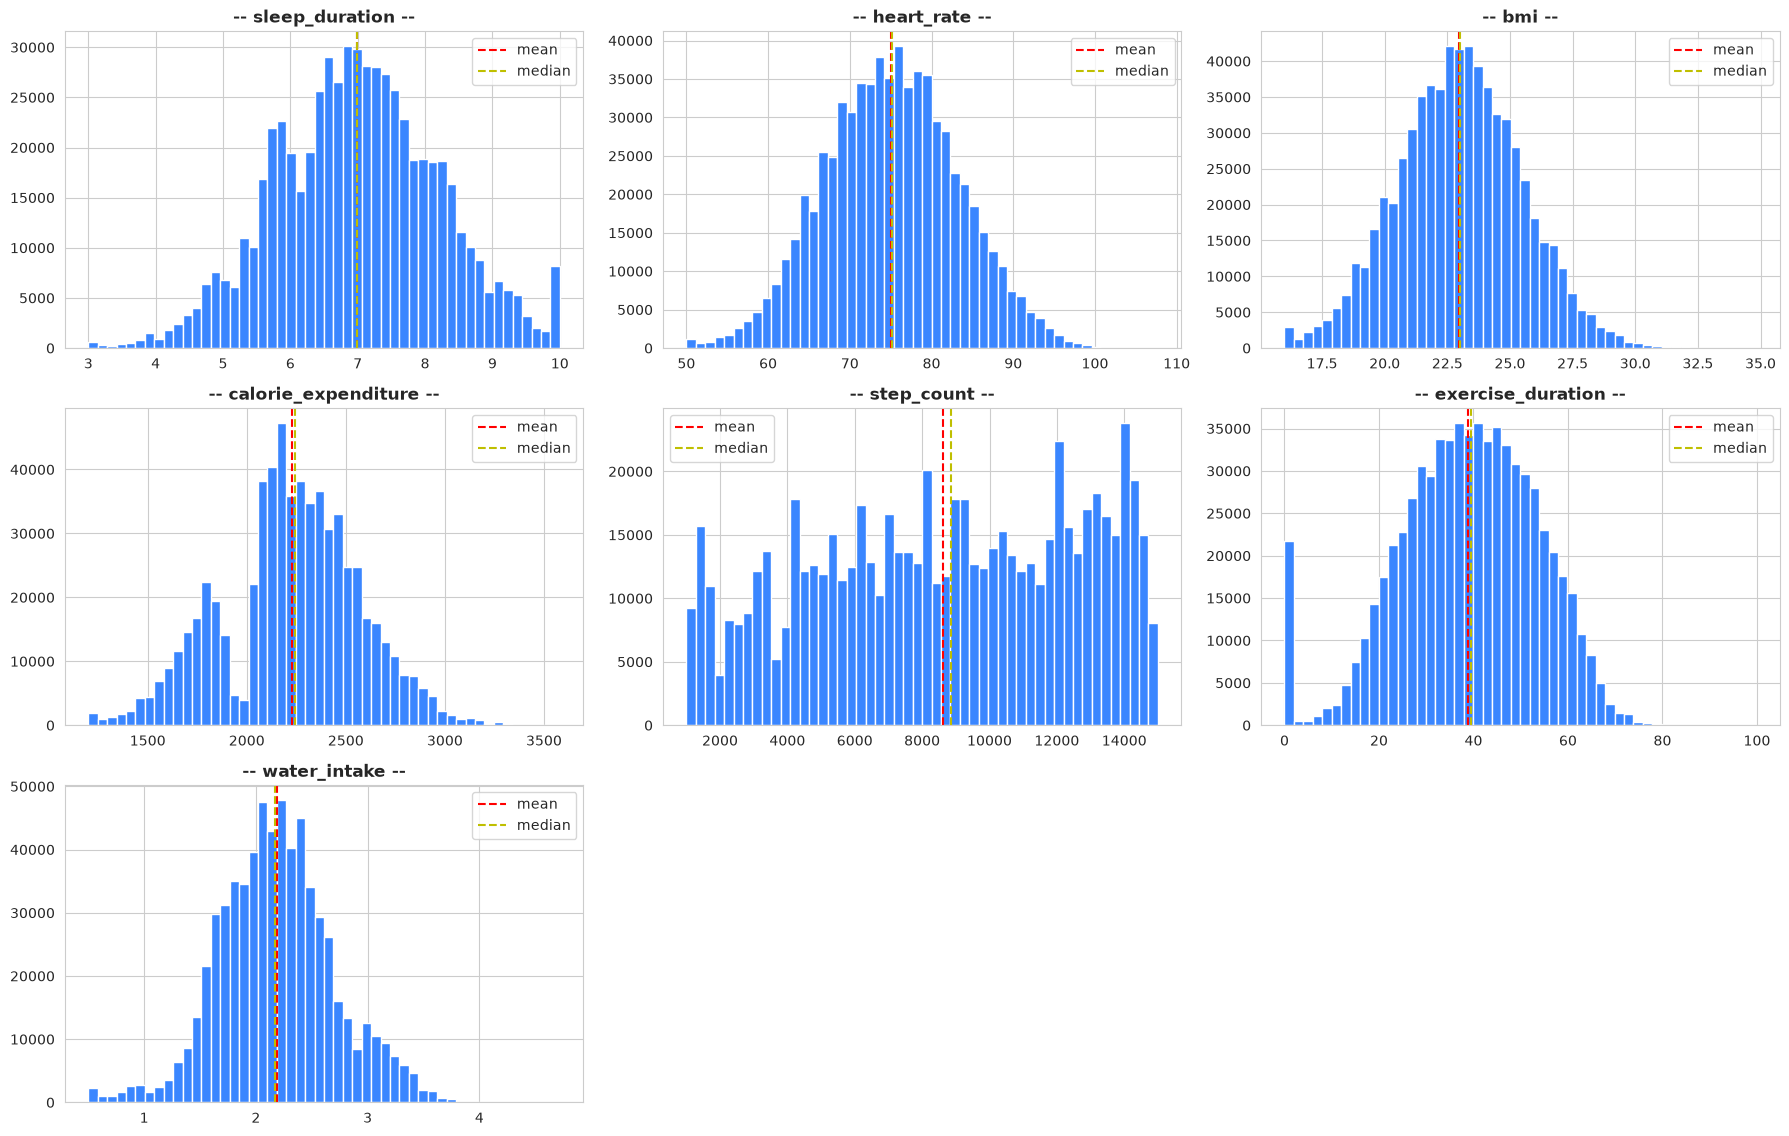

In [8]:
plt.figure(figsize=(18, 15))

for i, col in enumerate(NUMS):
    plt.subplot(4, 3, i+1)
    plt.hist(train[col], bins=50)
    plt.axvline(x=train[col].mean(), color='r', linestyle='--', label='mean')
    plt.axvline(x=train[col].median(), color='y', linestyle='--', label='median')
    plt.title(f'-- {col} --', fontweight='semibold')
    plt.legend()

plt.tight_layout()
plt.show()

In [9]:
## -- Unique value counts for each dataset --
TRAIN_UNIQUE = {}
ORIGINAL_UNIQUE = {}
TEST_UNIQUE = {}

for col in BASE:
    TRAIN_UNIQUE[col] = train[col].nunique()
    ORIGINAL_UNIQUE[col] = orig[col].nunique()
    TEST_UNIQUE[col] = test[col].nunique()

unique_counts_df = pd.concat(
        [pd.DataFrame(TRAIN_UNIQUE, index=['Train']),
         pd.DataFrame(ORIGINAL_UNIQUE, index=['Original']),
         pd.DataFrame(TEST_UNIQUE, index=['Test'])],
    )

unique_counts_df.style.background_gradient()

,sleep_duration,heart_rate,bmi,calorie_expenditure,step_count,exercise_duration,water_intake,diet_type,stress_level,sleep_quality,physical_activity_level,smoking_alcohol,gender
Train,701,537,1596,2101,12807,856,400,3,3,3,3,3,3
Original,700,585,1627,2179,13601,1041,412,3,3,3,3,3,3
Test,692,526,1548,2068,12196,817,392,3,3,3,3,3,3


In [10]:
n_unique = train[BASE].nunique().sort_values()
n_unique

diet_type                      3
physical_activity_level        3
sleep_quality                  3
gender                         3
smoking_alcohol                3
stress_level                   3
water_intake                 400
heart_rate                   537
sleep_duration               701
exercise_duration            856
bmi                         1596
calorie_expenditure         2101
step_count                 12807
dtype: int64

In [11]:
def get_class_weights(y):
    """
    y: Current y labels -> numpy array or series
    """
    cls_ = np.unique(y)
    wts_ = compute_class_weight('balanced', classes=cls_, y=y)
    return dict(zip([str(c) for c in cls_], wts_))

def get_sample_weights(y, y_true, opt='auto'):
    """
    y: Current y labels -> numpy array or series
    y_true: True labels -> numpy array or series
    opt: 'auto' generate weight or pass a custom dict -> label: weight
    """
    if opt != 'auto':
        return np.array([opt[label] for label in y])
    else:
        cls_ = np.unique(y_true)
        wts_ = compute_class_weight('balanced', classes=cls_, y=y_true)
        cls_wts = dict(zip(cls_, wts_))
        return np.array([cls_wts[label] for label in y])

def balanced_acc(y_true, y_proba):
    pred_labels = np.argmax(y_proba, axis=1)
    return balanced_accuracy_score(y_true, pred_labels)

def multi_class_brier(y_true, y_proba, classes):
    y_onehot = label_binarize(y_true, classes=classes)
    return float(np.mean(np.sum((y_onehot - y_proba) ** 2, axis=1)))

def t_enc_multi(X_tr, X_va, X_ts, y_tr, cols, drop=False):
    X_tr_1 = X_tr.copy()
    X_va_1 = X_va.copy()
    X_ts_1 = X_ts.copy()

    te_enc = TargetEncoder(target_type='multiclass', random_state=CFG['SEED']).set_output(transform='pandas')

    X_tr_te = te_enc.fit_transform(X_tr_1[cols], y_tr)
    X_va_te = te_enc.transform(X_va_1[cols])
    X_ts_te = te_enc.transform(X_ts_1[cols])

    te_names = [f"_TE_{c}" for c in X_tr_te.columns]
    X_tr_1[te_names] = X_tr_te
    X_va_1[te_names] = X_va_te
    X_ts_1[te_names] = X_ts_te

    if drop:
        X_tr_1 = X_tr_1.drop(columns=cols)
        X_va_1 = X_va_1.drop(columns=cols)
        X_ts_1 = X_ts_1.drop(columns=cols)

    return X_tr_1, X_va_1, X_ts_1

print('- Helper Functions Ready -')

- Helper Functions Ready -


In [12]:
get_class_weights(train[TARGET])

{'0': np.float64(5.779195873007898),
 '1': np.float64(0.38819519565636845),
 '2': np.float64(3.9849860254544613)}

## FEATURE ENGINEERING

In [13]:
## -- EXTRACTIONS & BINNING --
ROUNDS = []
DIGITS = []
E_BINS = []
Q_BINS = []
DROP_COLS = []

round_thresh = 3
digit_thresh = 2

round_thresh, digit_thresh

(3, 2)

In [14]:
# for col in ['delta']:
#     print(f"\nRounding... ", end='')
#     # for r in range(-2, 3):
#     #     r_n = f"{col}_round_{r}"
#     #     print(r_n+', ', end='')
#     #     train[r_n] = train[col].round(r).astype('int32')
#     #     test[r_n]  = test[col].round(r).astype('int32')
#     #     orig[r_n]  = orig[col].round(r).astype('int32')
#     #     ## -- Drop irrelevant features --
#     #     if train[r_n].nunique() < round_thresh or train[r_n].nunique() == train[col].nunique():
#     #         DROP_COLS.append(r_n)
#     #     else:
#     #         ROUNDS.append(r_n)

#     # print(f"\nDIGITS... ", end='')
#     # for d in range(-3, 4):
#     #     d_n = f'{col}_digit_{d}'
#     #     print(d_n+', ', end='')
#     #     train[d_n] = ((train[col] * 10**d) % 10).fillna(-1).astype('int8')
#     #     test[d_n]  = ((test[col]  * 10**d) % 10).fillna(-1).astype('int8')
#     #     orig[d_n]  = ((orig[col]  * 10**d) % 10).fillna(-1).astype('int8')

#     #     ## -- Drop constant features --
#     #     if train[d_n].nunique() < digit_thresh:
#     #         DROP_COLS.append(d_n)
#     #     else:
#     #         DIGITS.append(d_n)

#     # print(f"\nCreating value-based E_BINS... ", end='')
#     # for b in [100]:
#     #     b_n = f'{col}_bin_{b}'
#     #     print(b_n+', ', end='')
#     #     train[b_n], edges = pd.cut(train[col], bins=b, retbins=True, include_lowest=True, labels=False)
#     #     test[b_n] = pd.cut(test[col], bins=edges, include_lowest=True, labels=False)
#     #     orig[b_n] = pd.cut(orig[col], bins=edges, include_lowest=True, labels=False)
#     #     E_BINS.append(b_n)

#     print(f"\nCreating quantile-based Q_BINS... ", end='')
#     for q in [100]:
#         q_n = f'{col}_qbin_{q}'
#         print(q_n+', ', end='')
#         train[q_n], edges = pd.qcut(train[col], q=q, retbins=True, duplicates='drop', labels=False)
#         test[q_n] = pd.cut(test[col], bins=edges, include_lowest=True, labels=False)
#         orig[q_n] = pd.cut(orig[col], bins=edges, include_lowest=True, labels=False)
#         Q_BINS.append(q_n)

# print()
# print('-'*40)
# print(f'✅ ROUNDS: {len(ROUNDS)}')
# print(f"✅ DIGITS: {len(DIGITS)}")
# print(f"✅ E_BINS: {len(E_BINS)}")
# print(f"✅ Q_BINS: {len(Q_BINS)}")

In [15]:
# _extract_cols = ['RaceProgress'] # , 'LapTime_Delta'

# for col in _extract_cols:
#     # print(f"\nRounding... ", end='')
#     # for r in [0, -1]:
#     #     r_n = f"{col}_round_{r}"
#     #     print(r_n+', ', end='')
#     #     train[r_n] = train[col].round(r).astype('int32')
#     #     test[r_n]  = test[col].round(r).astype('int32')
#     #     orig[r_n]  = orig[col].round(r).astype('int32')

#     #     ## -- Drop irrelevant features --
#     #     if train[r_n].nunique() < round_thresh or train[r_n].nunique() == train[col].nunique():
#     #         DROP_COLS.append(r_n)
#     #     else:
#     #         ROUNDS.append(r_n)

#     # print(f"\nDIGITS... ", end='')
#     # for d in [-1, 0]:
#     #     d_n = f'{col}_digit_{d}'
#     #     print(d_n+', ', end='')
#     #     train[d_n] = ((train[col] * 10**d) % 10).fillna(-1).astype('int8')
#     #     test[d_n]  = ((test[col]  * 10**d) % 10).fillna(-1).astype('int8')
#     #     orig[d_n]  = ((orig[col]  * 10**d) % 10).fillna(-1).astype('int8')
#     #     ## -- Drop constant features --
#     #     if train[d_n].nunique() < digit_thresh:
#     #         DROP_COLS.append(d_n)
#     #     else:
#     #         DIGITS.append(d_n)

#     print(f"\nCreating value-based E_BINS... ", end='')
#     for b in [5]:
#         b_n = f'{col}_bin_{b}'
#         print(b_n+', ', end='')
#         train[b_n], edges = pd.cut(train[col], bins=b, retbins=True, include_lowest=True, labels=False)
#         test[b_n] = pd.cut(test[col], bins=edges, include_lowest=True, labels=False)
#         orig[b_n] = pd.cut(orig[col], bins=edges, include_lowest=True, labels=False)
#         E_BINS.append(b_n)

#     print(f"\nCreating quantile-based Q_BINS... ", end='')
#     for q in [5]:
#         q_n = f'{col}_Qbin_{q}'
#         print(q_n+', ', end='')
#         train[q_n], edges = pd.qcut(train[col], q=q, retbins=True, duplicates='drop', labels=False)
#         test[q_n] = pd.cut(test[col], bins=edges, include_lowest=True, labels=False)
#         orig[q_n] = pd.cut(orig[col], bins=edges, include_lowest=True, labels=False)
#         Q_BINS.append(q_n)

# print()
# print('-'*40)
# print(f'✅ Total ROUNDS: {len(ROUNDS)}')
# print(f"✅ Total DIGITS: {len(DIGITS)}")
# print(f"✅ Total E_BINS: {len(E_BINS)}")
# print(f"✅ Total Q_BINS: {len(Q_BINS)}")

In [16]:
train = train.drop(columns=DROP_COLS)
test  = test.drop(columns=DROP_COLS)
orig  = orig.drop(columns=DROP_COLS)

print(f"Features dropped: {DROP_COLS}")

Features dropped: []


In [17]:
# def add_frequency_condition(df1, cols, thresh=5):
#     df = df1.copy()
#     for c in cols:
#         # 1. Get value counts
#         v_counts = df[c].value_counts()
#         # 2. Identify values to replace (count <= threshold)
#         to_replace = v_counts[v_counts <= thresh].index
#         # 3. Apply condition: if value in low-freq list, assign 0, else keep it
#         df[c] = np.where(df[c].isin(to_replace), -1, df[c])

#     return df

# train = add_frequency_condition(train, DIGITS+ROUNDS, thresh=5)
# test  = add_frequency_condition(test,  DIGITS+ROUNDS, thresh=5)
# orig  = add_frequency_condition(orig,  DIGITS+ROUNDS, thresh=5)

# print(f"Frequency threshold imputed!")

In [18]:
# ## -- Arithmetic interaction --
# BANDS = ['u', 'g', 'r', 'i', 'z']
# COLOR_PAIRS = [
#     ('u', 'g'),
#     ('g', 'r'),
#     ('i', 'z'),
#     ('r', 'z'),
#     ('u', 'z'),
#     ('r', 'i'),
# ]

# for df in tqdm([train, test, orig]):
#     for a, b in COLOR_PAIRS:
#         df[f"_{a}_{b}"] = (df[a] - df[b]).astype('float32')

#     for band in BANDS:
#         # df[f"_div_{band}_redshift"] = (df[band] / (df['redshift'] + 1e-6)).astype('float32')
#         df[f"_div_abs_{band}_redshift"] = (df[band] / (df['redshift'].abs() + 1e-6)).astype('float32')

#     df['_sky_dist'] = np.sqrt(df['alpha']**2 + df['delta']**2)
#     df['_stellar_locus_dist'] = np.sqrt((df['_g_r'] - 0.52)**2 + (df['_r_i'] - 0.25)**2)

In [19]:
# ## -- Cyclical extraction --
# for df in tqdm([train, test, orig]):
#     for col in ['alpha']:
#         for p in [180, 360]:
#             df[f"{col}_{p}_sin_"] = np.sin(2 * np.pi * df[col] / p)
#             df[f"{col}_{p}_cos_"] = np.cos(2 * np.pi * df[col] / p)

# for df in tqdm([train, test, orig]):
#     for col in ['delta']:
#         for p in [180]:
#             df[f"{col}_{p}_sin_"] = np.sin(2 * np.pi * df[col] / p)
#             df[f"{col}_{p}_cos_"] = np.cos(2 * np.pi * df[col] / p)

# cyclic_cols = [c for c in train.columns if c.endswith('_sin_') or c.endswith('_cos_')]

# train[cyclic_cols].head()

In [20]:
# INTER = []

# for c1, c2 in tqdm(list(itertools.combinations(CATS, 2)), desc='Pairwise'):
#     n_col = f"Bi_{c1}-|-{c2}"
#     train[n_col] = train[c1].astype(str) + '_' + train[c2].astype(str)
#     test[n_col]  = test[c1].astype(str) + '_' + test[c2].astype(str)
#     orig[n_col]  = orig[c1].astype(str) + '_' + orig[c2].astype(str)
#     INTER.append(n_col)

# # for c1, c2, c3 in tqdm(list(itertools.combinations(top_cols, 3)), desc='Triplewise'):
# #     n_col = f"Tri_{c1}-|-{c2}-|-{c3}"
# #     train[n_col] = train[c1].astype(str) + '_' + train[c2].astype(str) + '_' + train[c3].astype(str)
# #     test[n_col]  = test[c1].astype(str) + '_' + test[c2].astype(str) + '_' + test[c3].astype(str)
# #     orig[n_col]  = orig[c1].astype(str) + '_' + orig[c2].astype(str) + '_' + test[c3].astype(str)
# #     INTER.append(n_col)

# # for c1, c2 in tqdm(list(itertools.product(top_cols, low_cols)), desc='One-to-Many'):
# #     n_col = f"Bi_{c1}-|-{c2}"
# #     train[n_col] = train[c1].astype(str) + '_' + train[c2].astype(str)
# #     test[n_col]  = test[c1].astype(str) + '_' + test[c2].astype(str)
# #     orig[n_col]  = orig[c1].astype(str) + '_' + orig[c2].astype(str)
# #     INTER.append(n_col)

# print(f"Total Interaction Features: {len(INTER)}")
# INTER

In [21]:
# ## -- Frequency encoding --
# freq_cols = []

# print(f"\nCreating frequencies... ", end='')
# for col in CATS:
#     freq = pd.concat([train[col], orig[col], test[col]]).value_counts(normalize=True)
#     n = f'{col}_freq'
#     print(f"{n}.. ", end='')
#     for df in [train, test, orig]:
#         df[n] = df[col].map(freq).fillna(0).astype('float32')
#     freq_cols.append(n)

# print(f"\n✓ Total frequency features: {len(freq_cols)}")
# train[freq_cols].describe()

In [22]:
# from sklearn.base import BaseEstimator, TransformerMixin ## ===== Target/Category Mean ENCODERS =====

# class TargetEncoder(BaseEstimator, TransformerMixin):
#     """
#     Target Encoder that supports multiple aggregation functions,
#     internal cross-validation for leakage prevention, and smoothing.

#     Parameters
#     ----------
#     cols_to_encode : list of str
#         List of column names to be target encoded.

#     aggs : list of str, default=['mean']
#         List of aggregation functions to apply. Any function accepted by
#         pandas' `.agg()` method is supported, such as:
#         'mean', 'std', 'var', 'min', 'max', 'skew', 'nunique', 
#         'count', 'sum', 'median'.
#         Smoothing is applied only to the 'mean' aggregation.

#     cv : int, default=5
#         Number of folds for cross-validation in fit_transform.

#     smooth : float or 'auto', default='auto'
#         The smoothing parameter `m`. A larger value puts more weight on the 
#         global mean. If 'auto', an empirical Bayes estimate is used.
        
#     drop_original : bool, default=False
#         If True, the original columns to be encoded are dropped.
#     """
#     def __init__(self, cols_to_encode, aggs=['mean'], cv=5, smooth='auto', drop_original=False):
#         self.cols_to_encode = cols_to_encode
#         self.aggs = aggs
#         self.cv = cv
#         self.smooth = smooth
#         self.drop_original = drop_original
#         self.mappings_ = {}
#         self.global_stats_ = {}

#     def fit(self, X, y):
#         """
#         Learn mappings from the entire dataset.
#         These mappings are used for the transform method on validation/test data.
#         """
#         temp_df = X.copy()
#         temp_df['target'] = y

#         # Learn global statistics for each aggregation
#         for agg_func in self.aggs:
#             self.global_stats_[agg_func] = y.agg(agg_func)

#         # Learn category-specific mappings
#         for col in self.cols_to_encode:
#             self.mappings_[col] = {}
#             for agg_func in self.aggs:
#                 mapping = temp_df.groupby(col)['target'].agg(agg_func)
#                 self.mappings_[col][agg_func] = mapping
        
#         return self

#     def transform(self, X):
#         """
#         Apply learned mappings to the data.
#         Unseen categories are filled with global statistics.
#         """
#         X_transformed = X.copy()
#         for col in self.cols_to_encode:
#             for agg_func in self.aggs:
#                 new_col_name = f'TE_{col}_{agg_func}'
#                 map_series = self.mappings_[col][agg_func]
#                 X_transformed[new_col_name] = X[col].map(map_series)
#                 X_transformed[new_col_name].fillna(self.global_stats_[agg_func], inplace=True)
        
#         if self.drop_original:
#             X_transformed.drop(columns=self.cols_to_encode, inplace=True)
            
#         return X_transformed

#     def fit_transform(self, X, y):
#         """
#         Fit and transform the data using internal cross-validation to prevent leakage.
#         """
#         # First, fit on the entire dataset to get global mappings for transform method
#         self.fit(X, y)

#         # Initialize an empty DataFrame to store encoded features
#         encoded_features = pd.DataFrame(index=X.index)
        
#         kf = KFold(n_splits=self.cv, shuffle=True, random_state=42)

#         for train_idx, val_idx in kf.split(X, y):
#             X_train, y_train = X.iloc[train_idx], y.iloc[train_idx]
#             X_val = X.iloc[val_idx]
            
#             temp_df_train = X_train.copy()
#             temp_df_train['target'] = y_train

#             for col in self.cols_to_encode:
#                 # --- Calculate mappings only on the training part of the fold ---
#                 for agg_func in self.aggs:
#                     new_col_name = f'TE_{col}_{agg_func}'
                    
#                     # Calculate global stat for this fold
#                     fold_global_stat = y_train.agg(agg_func)
                    
#                     # Calculate category stats for this fold
#                     mapping = temp_df_train.groupby(col)['target'].agg(agg_func)

#                     # --- Apply smoothing only for 'mean' aggregation ---
#                     if agg_func == 'mean':
#                         counts = temp_df_train.groupby(col)['target'].count()
                        
#                         m = self.smooth
#                         if self.smooth == 'auto':
#                             # Empirical Bayes smoothing
#                             variance_between = mapping.var()
#                             avg_variance_within = temp_df_train.groupby(col)['target'].var().mean()
#                             if variance_between > 0:
#                                 m = avg_variance_within / variance_between
#                             else:
#                                 m = 0  # No smoothing if no variance between groups
                        
#                         # Apply smoothing formula
#                         smoothed_mapping = (counts * mapping + m * fold_global_stat) / (counts + m)
#                         encoded_values = X_val[col].map(smoothed_mapping)
#                     else:
#                         encoded_values = X_val[col].map(mapping)
                    
#                     # Store encoded values for the validation fold
#                     encoded_features.loc[X_val.index, new_col_name] = encoded_values.fillna(fold_global_stat)

#         # Merge with original DataFrame
#         X_transformed = X.copy()
#         for col in encoded_features.columns:
#             X_transformed[col] = encoded_features[col]
            
#         if self.drop_original:
#             X_transformed.drop(columns=self.cols_to_encode, inplace=True)
            
#         return X_transformed


# class CategoryMeanTransformer(BaseEstimator, TransformerMixin):
#     def __init__(self, cat_cols=None):
#         self.cat_cols = cat_cols
#         self.mappings_ = {}
#     def fit(self, X, y):
#         X = X.copy()
#         if self.cat_cols is None:
#             self.cat_cols = X.select_dtypes(include=['category']).columns.tolist()
#         self.mappings_ = {}
#         for col in self.cat_cols:
#             df_temp = pd.DataFrame({col: X[col], 'y': y})
#             group_means = df_temp.groupby(col, dropna=False)['y'].mean()
#             sorted_categories = group_means.sort_values().index
#             self.mappings_[col] = {cat: i for i, cat in enumerate(sorted_categories)}
#         return self

#     def transform(self, X, y=None):
#         X = X.copy()
#         for col, mapping in self.mappings_.items():
#             if col in X.columns:
#                 X[col] = X[col].map(mapping)
#         return X

In [23]:
def orig_TE_data_propagate(
    orig: pd.DataFrame,
    X_train: pd.DataFrame,
    X_val: pd.DataFrame,
    X_test: pd.DataFrame,
    features: list=None,
    target: str=None,
    aggs: list=None,
    fill_nan: bool=False,
    ):

    if features is None or len(features) == 0:
        return X_train.copy(), X_val.copy(), X_test.copy(), []

    if aggs is None or len(aggs) == 0:
        return X_train.copy(), X_val.copy(), X_test.copy(), []

    X_train_df = X_train.copy()
    X_val_df   = X_val.copy()
    X_test_df  = X_test.copy()
    ORIG = []

    maps = {}

    valid_features = [col for col in features if col in orig.columns]

    for col in tqdm(valid_features, desc='TE_merging'):
        for agg_ in aggs:
            agg_key = agg_.lower()
            new_col = f"OTE_{col}_{agg_key}"

            map_key = (col, agg_key)
            if map_key not in maps:
                try:
                    if agg_key == 'mean':
                        map_df = (orig.groupby(col)[target].mean().reset_index(name=new_col))
                    elif agg_key == 'median':
                        map_df = (orig.groupby(col)[target].median().reset_index(name=new_col))
                    elif agg_key == 'count':
                        map_df = (orig.groupby(col).size().reset_index(name=new_col)) #.astype('int32')
                    elif agg_key == 'nunique':
                        map_df = (orig.groupby(col)[target].nunique().reset_index(name=new_col)) #.astype('int32')
                    elif agg_key == 'std':
                        map_df = (orig.groupby(col)[target].std().reset_index(name=new_col))
                    elif agg_key == 'skew':
                        map_df = (orig.groupby(col)[target].skew().reset_index(name=new_col))
                    elif agg_key == 'max':
                        map_df = (orig.groupby(col)[target].max().reset_index(name=new_col))
                    elif agg_key == 'min':
                        map_df = (orig.groupby(col)[target].min().reset_index(name=new_col))
                    else:
                        continue
                except Exception as e:
                    print(f"Warning: failed to create map for col={col}, agg={agg_}: {e}")
                    continue

                maps[map_key] = map_df

            map_df = maps.get(map_key)
            if map_df is None:
                continue

            # Merge maps into each split
            X_train_df = X_train_df.merge(map_df, on=col, how='left')
            X_val_df   = X_val_df.merge(map_df, on=col, how='left')
            X_test_df  = X_test_df.merge(map_df, on=col, how='left')

            ORIG.append(new_col)

    global_mean   = orig[target].mean()
    global_median = orig[target].median()

    def fill_conditionally(df):
        for c in ORIG:
            if '_mean' in c or '_max' in c or '_min' in c:
                df[c] = df[c].fillna(global_mean)
            elif '_median' in c:
                df[c] = df[c].fillna(global_median)
            else:
                df[c] = df[c].fillna(0)
        return df

    if fill_nan:
        X_train_df = fill_conditionally(X_train_df)
        X_val_df   = fill_conditionally(X_val_df)
        X_test_df  = fill_conditionally(X_test_df)

    return X_train_df, X_val_df, X_test_df, ORIG

In [24]:
# train, test, _, ORIG_COLS = orig_TE_data_propagate(
#     orig,
#     train,
#     test,
#     train.iloc[:500],
#     features=BASE, #+DIGITS, #+ROUNDS,
#     target=TARGET,
#     aggs=['mean'], # mean, median, count, std, skew, nunique, max, min
#     # fill_nan=True,
# )

In [25]:
# ## -- Duplicate Nums as Cats --
# CATS_2 = []
# nums_cats = ['_LapNumber_/_RaceProgress', '_TyreLife_/_LapNumber'] #+ orig_cols

# for c in nums_cats:
#     n = f"cat_{c}"
#     train[n] = train[c].copy()
#     test[n]  = test[c].copy()
#     CATS_2.append(n)

#     ## -- Factorize --
#     combine  = pd.concat([train[n], test[n]])
#     __ = combine.factorize()[0]
#     train[n] = __[:len(train)].astype('int32')
#     test[n]  = __[len(train):].astype('int32')

# print(f'Nums to Cats: {len(CATS_2)}')
# CATS_2

In [26]:
# ## -- Factorize combined data --
# for c in CATS:
#     combined = pd.concat([train[c], test[c], orig[c]])
#     combined = combined.factorize()[0]
#     # combine  = pd.Series(combine).astype('category')
#     train[c] = combined[:len(train)]
#     test[c]  = combined[len(train):len(train)+len(test)]
#     orig[c]  = combined[-len(orig):]

# print('Label encoding complete!')

In [27]:
FEATURES = [c for c in train.columns if c not in [ID, TARGET]]
print('Total Features:', len(FEATURES))

train

Total Features: 13


,id,health_condition,sleep_duration,heart_rate,bmi,calorie_expenditure,step_count,exercise_duration,water_intake,diet_type,stress_level,sleep_quality,physical_activity_level,smoking_alcohol,gender
0,0,2,5.22,70.6,25.66,2174.0,1326.0,19.8,1.86,veg,high,average,sedentary,yes,female
1,1,1,5.53,71.3,25.84,1966.0,9891.0,49.9,1.26,non-veg,low,average,moderate,yes,other
2,2,2,5.29,75.4,24.54,2688.0,14216.0,38.1,1.60,veg,high,poor,active,yes,male
3,3,2,4.70,77.2,23.13,2630.0,7174.0,59.9,2.02,veg,high,average,active,occasional,female
4,4,1,7.23,73.4,28.44,2560.0,6584.0,46.0,2.25,veg,NaN,average,sedentary,NaN,male
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
690083,690083,1,6.31,69.7,24.11,2157.0,NaN,30.8,3.00,non-veg,high,poor,active,yes,female
690084,690084,1,5.78,54.0,26.36,2858.0,6488.0,52.4,1.46,veg,medium,average,moderate,no,male
690085,690085,0,7.64,85.7,21.91,2195.0,9241.0,41.3,1.57,non-veg,NaN,average,active,no,male
690086,690086,1,6.74,73.0,18.73,2061.0,13366.0,56.6,2.60,balanced,NaN,average,active,yes,male


# ML TRAINING

In [28]:
try:
    from venn_abers import VennAbersCalibrator
    # from cir_model import CenteredIsotonicRegression
except:
    %pip install -q -U venn-abers
    from venn_abers import VennAbersCalibrator
    # from cir_model import CenteredIsotonicRegression

print()

!pip show venn_abers


[notice] A new release of pip is available: 25.0.1 -> 26.1.2
[notice] To update, run: pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.



Name: venn-abers
Version: 1.5.3
Summary: Venn-ABERS calibration package
Home-page: https://github.com/ip200/venn-abers
Author: Ivan Petej
Author-email: ivan@algorhythmic.ai
License: MIT
Location: /usr/local/lib/python3.12/site-packages
Requires: numpy, pandas, scikit-learn
Required-by: 


In [29]:
def Trainer_CV(
    model_name, params, train_df, test_df, features, target,
    kfold, cat_cols, verbosity, use_weights=False, calibrate=False):
    print(f"\n===== Starting CV: {model_name} =====")
    start = time()

    X = train_df[features]
    y = train_df[target]
    
    num_cls = y.nunique()
    
    oof_preds = np.zeros((len(X), num_cls))
    test_preds = np.zeros((len(test_df), num_cls))

    fold_scores = []
    brier_scores = []

    for idx, (train_idx, val_idx) in enumerate(kfold.split(X, y)):
        print(f"\n***** FOLD {idx+1}/{kfold.n_splits} | ", end='')

        # Split data for the current fold
        X_train, X_valid = X.iloc[train_idx], X.iloc[val_idx]
        y_train, y_valid = y.iloc[train_idx], y.iloc[val_idx]
        X_test = test_df[features].copy()

        ## -- OPTION A: Concatenate original data --
        # X_train = pd.concat([X_train, orig[features]], ignore_index=True)
        # y_train = pd.concat([y_train, orig[target]], ignore_index=True)
        # y_train = np.concatenate([y_train, orig[TARGET].values], axis=0)

        # ## -- Target Encoding --
        # te_cols = INTER
        # print(f" • Target Encoding {len(te_cols)} features... ")
        # X_train, X_valid, X_test = t_enc_multi(X_train, X_valid, X_test, y_train, te_cols, drop=True)

        # ## -- TE Opt1. -> Using custom script --
        # te_enc = TargetEncoder(INTER, cv=5, smooth='auto', aggs=['mean'], drop_original=True)
        # X_train = te_enc.fit_transform(X_train, y_train)
        # X_valid = te_enc.transform(X_valid)
        # X_test  = te_enc.transform(X_test)

        # cm_enc  = CategoryMeanTransformer(cat_cols=ROUNDS)
        # X_train = cm_enc.fit_transform(X_train, y_train)
        # X_valid = cm_enc.transform(X_valid)
        # X_test  = cm_enc.transform(X_test)

        # combined = pd.concat([X_train, X_valid, X_test])
        # for c in cats:
        #     combined[c] = combined[c].astype(str) #.astype('category')

        # X_train = combined.iloc[:len(X_train)]
        # X_valid = combined.iloc[len(X_train):len(X_train)+len(X_valid)]
        # X_test  = combined.iloc[len(X_train)+len(X_valid):]

        print(f"Train shape: {X_train.shape} -")

        ## -- Internal Split for Calibration --
        X_base, X_calib, y_base, y_calib = train_test_split(
            X_train, y_train, train_size=0.75, stratify=y_train, random_state=CFG['SEED']
        )

        if calibrate:
            # ## -- To enable ydf read numerical as categories --
            # flat_features = []
            # for f in cats: 
            #     flat_features.append(ydf.Feature(f, ydf.Semantic.CATEGORICAL))

            print(f" • Training ydf model {X_base.shape}... ")
            ## -- Build YDF model --
            model = ydf.GradientBoostedTreesLearner(
                **params,
                label=target,
                class_weights=get_class_weights(y_train) if use_weights else None,
                # features=flat_features,   # 1. Semantic for categories goes here
                # include_all_columns=True, # 2. Include all features for training
            ).train(
                ds=pd.concat([X_base, y_base], axis=1),
                valid=pd.concat([X_valid, y_valid], axis=1),
                verbose=verbosity,
            )

            ydf_acc   = balanced_acc(y_valid, model.predict(X_valid))
            ydf_brier = multi_class_brier(y_valid, model.predict(X_valid), np.unique(y_valid))

            ## -- Calibrate outputs --
            print(f" • Calibrating (venn-abers) {X_calib.shape}... ")
            vao = VennAbersCalibrator() # - Get OOF predictions -
            venn_oof_preds = vao.predict_proba(
                p_cal   = model.predict(X_calib),
                y_cal   = y_calib.to_numpy(),
                p_test  = model.predict(X_valid),
                va_type = 'one_vs_all',
            )
            oof_preds[val_idx] = venn_oof_preds

            vat = VennAbersCalibrator() # - Get TEST predictions -
            venn_test_preds = vat.predict_proba(
                p_cal   = model.predict(X_calib),
                y_cal   = y_calib.to_numpy(),
                p_test  = model.predict(X_test),
                va_type = 'one_vs_all',
            )

            test_preds += venn_test_preds

            ## -- Fold scores --
            fold_score  = balanced_acc(y_valid, oof_preds[val_idx])
            brier_score = multi_class_brier(y_valid, oof_preds[val_idx], np.unique(y_valid))

            fold_scores.append(fold_score)
            brier_scores.append(brier_score)
            print(f"{CFG['YELLOW']} • Fold {idx+1}")
            print(f"base_acc:  {ydf_acc:.5f} | base_brier:  {ydf_brier:.5f}")
            print(f"calib_acc: {fold_score:.5f} | calib_brier: {brier_score:.5f}")
            print(f"{CFG['RESET']}")
        else:
            # ## -- To enable ydf read numerical as categories --
            # flat_features = []
            # for f in cats: 
            #     flat_features.append(ydf.Feature(f, ydf.Semantic.CATEGORICAL))

            ## -- Build YDF model --
            model = ydf.GradientBoostedTreesLearner(
                **params,
                label=target,
                class_weights=get_class_weights(y_train) if use_weights else None,
                # features=flat_features,   # 1. Semantic for categories goes here
                # include_all_columns=True, # 2. Include all features for training
            ).train(
                ds=pd.concat([X_train, y_train], axis=1),
                valid=pd.concat([X_valid, y_valid], axis=1),
                verbose=verbosity,
            )

            ## -- Predict on val and test sets --
            oof_preds[val_idx] = model.predict(X_valid)
            test_preds += model.predict(X_test)

            ## -- Calculate and print fold score --
            fold_score  = balanced_acc(y_valid, oof_preds[val_idx])
            brier_score = multi_class_brier(y_valid, oof_preds[val_idx], np.unique(y_valid))

            fold_scores.append(fold_score)
            brier_scores.append(brier_score)
            print(f"{CFG['YELLOW']} • Fold {idx+1} acc: {fold_score:.5f} | brier: {brier_score:.5f}{CFG['RESET']}")

        # ## -- Clean up memory --
        # del y_train, y_valid, X_test
        # gc.collect() 

    ## -- Average the test predictions --
    test_preds /= kfold.n_splits

    ## -- CV results --
    print("\n==================================================")
    print(f"{kfold.n_splits}-FOLD CV: {model_name}")
    print("==================================================")
    for i, (a, b) in enumerate(zip(fold_scores, brier_scores), 1):
        print(f" • Fold {i} score: {a:.5f} | brier: {b:.5f}")

    ## -- Final out-of-fold score --
    oof_score = np.round(balanced_acc(y, oof_preds), 5)
    oof_brier = np.round(multi_class_brier(y, oof_preds, np.unique(y)), 5)

    print("-------------------------------------------------|")
    print(f"OOF score: {oof_score}")
    print(f"AVG score: {np.mean(fold_scores):.5f} ± {np.std(fold_scores):.5f}")
    print("-------------------------------------------------|")
    print(f"OOF brier: {oof_brier}")
    print(f"AVG brier: {np.mean(brier_scores):.5f} ± {np.std(brier_scores):.5f}")
    print("-------------------------------------------------|")
    print(f'{((time() - start) / 60):.2f} mins')

    return {
        'oof_preds': oof_preds,
        'test_preds': test_preds,
        'scores': oof_score,
        'model': model,
        'data': pd.concat([X_valid, y_valid], axis=1), 
    }

print("⚙️ Training function ready ⚙️")

⚙️ Training function ready ⚙️


### HYPER_SPACE_SEARCH

In [30]:
get_class_weights(train[TARGET])

{'0': np.float64(5.779195873007898),
 '1': np.float64(0.38819519565636845),
 '2': np.float64(3.9849860254544613)}

In [31]:
VERS = 'ydf_' # 8FOLDS_fe0_GLOBAL_no_calib
all_predictions = {}

MULTI_SEEDS = [CFG['SEED'], 777, 1234, 24611, 0]
ALL_CATS = CATS

CFG['FOLDS'] = 5
skf = StratifiedKFold(n_splits=CFG['FOLDS'], shuffle=True, random_state=CFG['SEED'])

USE_FULL_TRAIN = True
USE_CALIBATOR  = False

x_sample, x_sample2 = train_test_split(train, train_size=0.3, stratify=train[TARGET], random_state=0)
train_data = train.copy() if USE_FULL_TRAIN else x_sample.copy()

train_data

,id,health_condition,sleep_duration,heart_rate,bmi,calorie_expenditure,step_count,exercise_duration,water_intake,diet_type,stress_level,sleep_quality,physical_activity_level,smoking_alcohol,gender
0,0,2,5.22,70.6,25.66,2174.0,1326.0,19.8,1.86,veg,high,average,sedentary,yes,female
1,1,1,5.53,71.3,25.84,1966.0,9891.0,49.9,1.26,non-veg,low,average,moderate,yes,other
2,2,2,5.29,75.4,24.54,2688.0,14216.0,38.1,1.60,veg,high,poor,active,yes,male
3,3,2,4.70,77.2,23.13,2630.0,7174.0,59.9,2.02,veg,high,average,active,occasional,female
4,4,1,7.23,73.4,28.44,2560.0,6584.0,46.0,2.25,veg,NaN,average,sedentary,NaN,male
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
690083,690083,1,6.31,69.7,24.11,2157.0,NaN,30.8,3.00,non-veg,high,poor,active,yes,female
690084,690084,1,5.78,54.0,26.36,2858.0,6488.0,52.4,1.46,veg,medium,average,moderate,no,male
690085,690085,0,7.64,85.7,21.91,2195.0,9241.0,41.3,1.57,non-veg,NaN,average,active,no,male
690086,690086,1,6.74,73.0,18.73,2061.0,13366.0,56.6,2.60,balanced,NaN,average,active,yes,male


In [32]:
# %%time

# ## -- Search HPO space for 'LOCAL' & 'BEST_FIRST_GLOBAL' --

# tuner = ydf.RandomSearchTuner(num_trials=20, automatic_search_space=False)
# # tuner.choice('num_trees', [5000, 2000])
# # tuner.choice('shrinkage', [0.02, 0.05]) 
# # tuner.choice('subsample', [0.9, 1.0])
# tuner.choice('categorical_algorithm', ['CART', 'RANDOM']) #'CART', 'RANDOM', 'ONE_HOT'
# # tuner.choice('l2_regularization', [0.05, 0.1, 0.2, 0.5, 1.0])

# ## -- 'LOCAL' acts like 'depthwise': uses 'max_depth' --
# local_subspace = tuner.choice('growing_strategy', ['LOCAL'])
# local_subspace.choice('max_depth', [4, 6, 8])

# # ## -- 'BEST_FIRST_GLOBAL' acts like 'lossguide': uses 'max_num_nodes' --
# global_subspace = tuner.choice('growing_strategy', ['BEST_FIRST_GLOBAL'], merge=True)
# # global_subspace.choice('max_num_nodes', [None, 32, 64, 128])

# # ## -- Enable ydf process numeric features as categories --
# # num_as_cat = []
# # for f in CATS:
# #     num_as_cat.append(ydf.Feature(f, ydf.Semantic.CATEGORICAL))

# ydf_HPO_model = ydf.GradientBoostedTreesLearner(
#     task=ydf.Task.CLASSIFICATION,
#     label=TARGET, 
#     tuner=tuner,
#     num_trees=1000,
#     shrinkage=0.1,
#     class_weights=get_class_weights(train_data[TARGET]), ## 
#     # max_depth=4,
#     # features=num_as_cat,
#     # include_all_columns=True,
#     # l2_regularization=0.15,
#     # categorical_algorithm='RANDOM',
#     early_stopping_initial_iteration=10,
#     early_stopping_num_trees_look_ahead=50,
#     random_seed=CFG['SEED'], 
#     num_threads=os.cpu_count(), 
# ).train(train_data, verbose=1)

# ydf_HPO_model.describe()

In [33]:
# ydf_HPO_model.evaluate(x_sample2, weighted=True)

In [34]:
# ydf_HPO_model.plot_tree()

In [35]:
# optimizer_logs = ydf_HPO_model.hyperparameter_optimizer_logs()
# print("Total number of trials:", len(optimizer_logs.trials))

# # # Accessing the first trial
# # first_trial = optimizer_logs.trials[0]
# # print(f"\nFirst Trial Score (absolute): {abs(first_trial.score):.4f}")
# # print("First Trial Parameters:")
# # for param, value in first_trial.params.items():
# #     print(f"  {param}: {value}")

# # Iterate through all trials to find the best one (smallest absolute score)
# best_abs_score = float('inf') # Initialize to a very large number for minimization
# best_params = None

# for i, trial in enumerate(optimizer_logs.trials):
#     current_abs_score = abs(trial.score)
#     print(f"\nTrial {i+1}: Score (abs) = {current_abs_score:.5f}")
#     # print(f"  Parameters: {trial.params}") # Uncomment to see all parameters for each trial

#     if current_abs_score < best_abs_score:
#         best_abs_score = current_abs_score
#         best_params = trial.params

# print(f"\nBest Trial Score (abs): {best_abs_score:.5f}") 
# print("Best Trial Parameters:")
# if best_params:
#     for param, value in best_params.items():
#         print(f"  {param}: {value}")

# param_df = pd.Series(data=best_params, dtype='str', name='ydf_HPO_params')
# param_df.to_csv('ydf_best_params.csv', index=False)

# param_df

In [36]:
PARAMS = {
    'task': ydf.Task.CLASSIFICATION,
    'growing_strategy': 'LOCAL',
    'num_trees': 1000,
    'max_depth': 6,
    # 'shrinkage': 0.05,
    'categorical_algorithm': 'CART', # 'CART', 'RANDOM', 'ONE_HOT'
    # 'sampling_method': 'RANDOM', # 'RANDOM', 'GOSS', 'SELGB'
    # 'split_axis': , # 'AXIS_ALIGNED', 'SPARSE_OBLIQUE', 'MHLD_OBLIQUE'
    # 'subsample': 0.95, # default RANDOM sampling
    # 'goss_alpha': 0.2, # activates GOSS sampling
    # 'l2_regularization': 1.0,
    'early_stopping_initial_iteration': 10,
    'early_stopping_num_trees_look_ahead': 100,
    'random_seed': CFG['SEED'],
}

# n = f"{VERS}local_calib_" if USE_CALIBATOR else f"{VERS}local_"
for algo in ['CART', 'RANDOM']:
    PARAMS['categorical_algorithm'] = algo
    n = f"{VERS}local_calib_{str(algo).lower()}" if USE_CALIBATOR else f"{VERS}local_{str(algo).lower()}"
    all_predictions[n] = Trainer_CV(
        model_name=n,
        params=PARAMS,
        train_df=train_data,
        test_df=test,
        features=FEATURES,
        target=TARGET,
        kfold=skf,
        cat_cols=ALL_CATS,
        use_weights=True,
        calibrate=USE_CALIBATOR,
        verbosity=1,
    )


===== Starting CV: ydf_local_cart =====

***** FOLD 1/5 | Train shape: (552070, 13) -


Train model on 552070 training examples and 138018 validation examples


Model trained in 0:01:13.829005


 • Fold 1 acc: 0.95096 | brier: 0.09236

***** FOLD 2/5 | Train shape: (552070, 13) -


Train model on 552070 training examples and 138018 validation examples


...

Model trained in 0:00:51.550664


 • Fold 4 acc: 0.94938 | brier: 0.09239

***** FOLD 5/5 | Train shape: (552071, 13) -


Train model on 552071 training examples and 138017 validation examples


Model trained in 0:00:56.437745


 • Fold 5 acc: 0.94798 | brier: 0.09275

5-FOLD CV: ydf_local_random
 • Fold 1 score: 0.95075 | brier: 0.09315
 • Fold 2 score: 0.95141 | brier: 0.09274
 • Fold 3 score: 0.94893 | brier: 0.09362
 • Fold 4 score: 0.94938 | brier: 0.09239
 • Fold 5 score: 0.94798 | brier: 0.09275
-------------------------------------------------|
OOF score: 0.94969
AVG score: 0.94969 ± 0.00124
-------------------------------------------------|
OOF brier: 0.09293
AVG brier: 0.09293 ± 0.00042
-------------------------------------------------|
5.19 mins


In [37]:
# ==================================================
# 5-FOLD CV: ydf_local_cart | (552071, 13)
# ==================================================
#  • Fold 1 score: 0.95096 | brier: 0.09236
#  • Fold 2 score: 0.95151 | brier: 0.09253
#  • Fold 3 score: 0.94902 | brier: 0.09318
#  • Fold 4 score: 0.94953 | brier: 0.09215
#  • Fold 5 score: 0.94821 | brier: 0.09274
# -------------------------------------------------|
# OOF score: 0.94985
# AVG score: 0.94985 ± 0.00122
# -------------------------------------------------|
# OOF brier: 0.09259
# AVG brier: 0.09259 ± 0.00035
# -------------------------------------------------|
# 5.81 mins

# ==================================================
# 5-FOLD CV: ydf_local_random | (552071, 13)
# ==================================================
#  • Fold 1 score: 0.95075 | brier: 0.09315
#  • Fold 2 score: 0.95141 | brier: 0.09274
#  • Fold 3 score: 0.94893 | brier: 0.09362
#  • Fold 4 score: 0.94938 | brier: 0.09239
#  • Fold 5 score: 0.94798 | brier: 0.09275
# -------------------------------------------------|
# OOF score: 0.94969
# AVG score: 0.94969 ± 0.00124
# -------------------------------------------------|
# OOF brier: 0.09293
# AVG brier: 0.09293 ± 0.00042
# -------------------------------------------------|
# 5.14 mins

In [38]:
# __ = ydf.GradientBoostedTreesLearner()

PARAMS = {
    'task': ydf.Task.CLASSIFICATION,
    'growing_strategy': 'BEST_FIRST_GLOBAL',
    'num_trees': 1000,
    # 'max_num_nodes': None,
    # 'shrinkage': 0.05,
    'categorical_algorithm': 'RANDOM', # 'CART', 'RANDOM', 'ONE_HOT'
    # 'sampling_method': 'RANDOM', # 'RANDOM', 'GOSS', 'SELGB'
    # 'split_axis': , # 'AXIS_ALIGNED', 'SPARSE_OBLIQUE', 'MHLD_OBLIQUE'
    # 'subsample': 0.95, # default RANDOM sampling
    # 'goss_alpha': 0.2, # activates GOSS sampling
    # 'l2_regularization': 1.0,
    'early_stopping_initial_iteration': 10,
    'early_stopping_num_trees_look_ahead': 100,
    'random_seed': CFG['SEED'],
}

# n = f"{VERS}global_calib_" if USE_CALIBATOR else f"{VERS}global_"
for algo in ['CART', 'RANDOM']:
    PARAMS['categorical_algorithm'] = algo
    n = f"{VERS}global_calib_{str(algo).lower()}" if USE_CALIBATOR else f"{VERS}global_{str(algo).lower()}"
    all_predictions[n] = Trainer_CV(
        model_name=n,
        params=PARAMS,
        train_df=train_data,
        test_df=test,
        features=FEATURES,
        target=TARGET,
        kfold=skf,
        cat_cols=ALL_CATS,
        use_weights=True,
        calibrate=USE_CALIBATOR,
        verbosity=1,
    )


===== Starting CV: ydf_global_cart =====



***** FOLD 1/5 | Train shape: (552070, 13) -


Train model on 552070 training examples and 138018 validation examples


Model trained in 0:00:50.737482


 • Fold 1 acc: 0.95075 | brier: 0.09248

***** FOLD 2/5 | Train shape: (552070, 13) -


...

Model trained in 0:00:56.499415


 • Fold 4 acc: 0.94923 | brier: 0.09113

***** FOLD 5/5 | Train shape: (552071, 13) -


Train model on 552071 training examples and 138017 validation examples


Model trained in 0:00:46.942994


 • Fold 5 acc: 0.94781 | brier: 0.09292

5-FOLD CV: ydf_global_random
 • Fold 1 score: 0.95053 | brier: 0.09139
 • Fold 2 score: 0.95126 | brier: 0.09246
 • Fold 3 score: 0.94888 | brier: 0.09362
 • Fold 4 score: 0.94923 | brier: 0.09113
 • Fold 5 score: 0.94781 | brier: 0.09292
-------------------------------------------------|
OOF score: 0.94954
AVG score: 0.94954 ± 0.00122
-------------------------------------------------|
OOF brier: 0.09231
AVG brier: 0.09231 ± 0.00093
-------------------------------------------------|
4.81 mins


In [39]:
# ==================================================
# 5-FOLD CV: ydf_global_cart | (552071, 13)
# ==================================================
#  • Fold 1 score: 0.95075 | brier: 0.09248
#  • Fold 2 score: 0.95156 | brier: 0.09260
#  • Fold 3 score: 0.94900 | brier: 0.09426
#  • Fold 4 score: 0.94965 | brier: 0.09200
#  • Fold 5 score: 0.94793 | brier: 0.09323
# -------------------------------------------------|
# OOF score: 0.94978
# AVG score: 0.94978 ± 0.00128
# -------------------------------------------------|
# OOF brier: 0.09291
# AVG brier: 0.09291 ± 0.00078
# -------------------------------------------------|
# 3.98 mins

# ==================================================
# 5-FOLD CV: ydf_global_random | (552071, 13)
# ==================================================
#  • Fold 1 score: 0.95053 | brier: 0.09139
#  • Fold 2 score: 0.95126 | brier: 0.09246
#  • Fold 3 score: 0.94888 | brier: 0.09362
#  • Fold 4 score: 0.94923 | brier: 0.09113
#  • Fold 5 score: 0.94781 | brier: 0.09292
# -------------------------------------------------|
# OOF score: 0.94954
# AVG score: 0.94954 ± 0.00122
# -------------------------------------------------|
# OOF brier: 0.09231
# AVG brier: 0.09231 ± 0.00093
# -------------------------------------------------|
# 4.40 mins

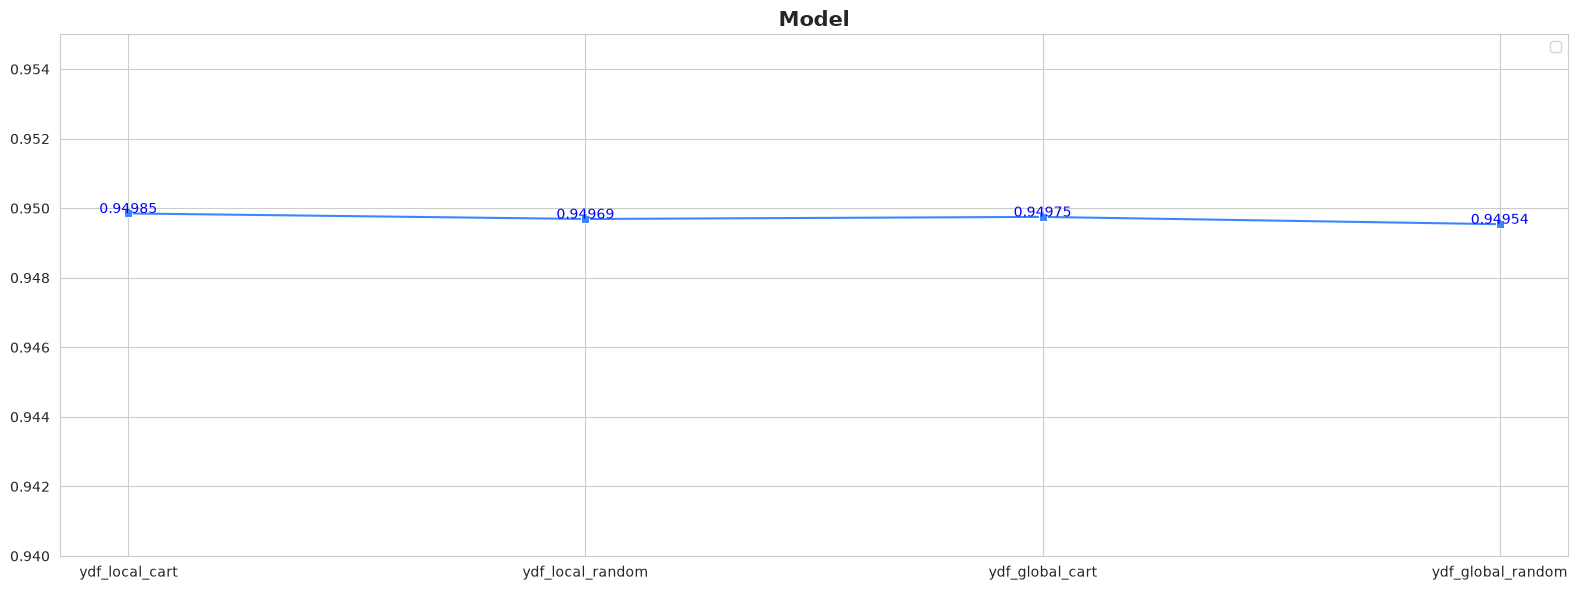

In [40]:
## -- Get Scores --
all_scores = {}

for i, (k, v) in enumerate(all_predictions.items()):
    for x, y in v.items():
        if x == 'scores':
            all_scores[k] = y

plt.figure(figsize=(16, 6))
ax1 = sns.lineplot([*all_scores.values()], marker='s')

y_add = 1e-5

for i, s1 in enumerate([*all_scores.values()]):
    ax1.text(float(i), s1+y_add, s1, ha='center', va='baseline', color='b')

plt.ylim((0.94, 0.955))
plt.legend(loc='best')
plt.xticks(range(len(all_scores)), [*all_scores.keys()], rotation=0)
plt.title('Model', fontdict={'weight': 'semibold', 'size': 15})

plt.tight_layout() 
plt.show()

ydf_local_cart_94985 saved!


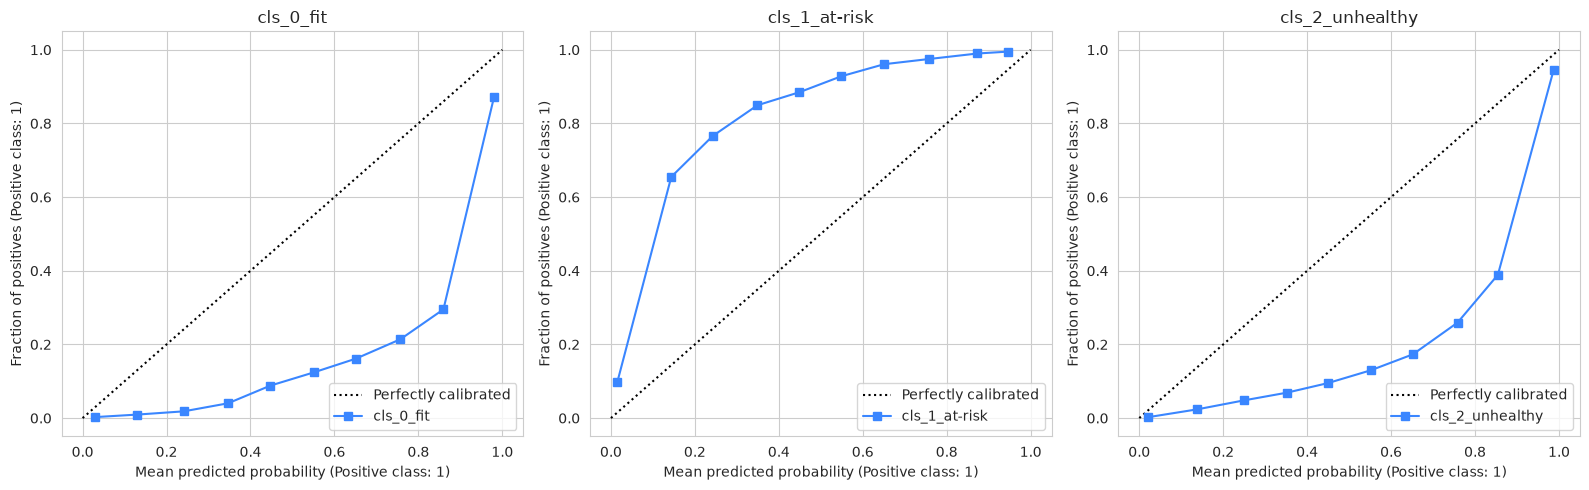

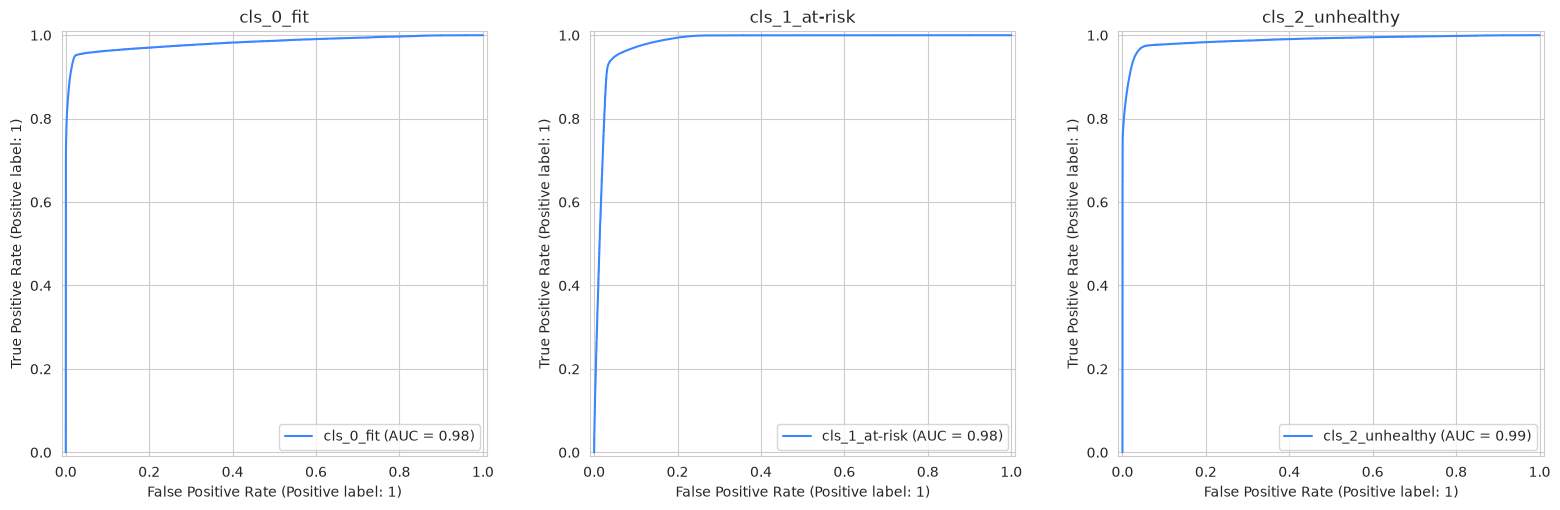


ydf_local_random_94969 saved!


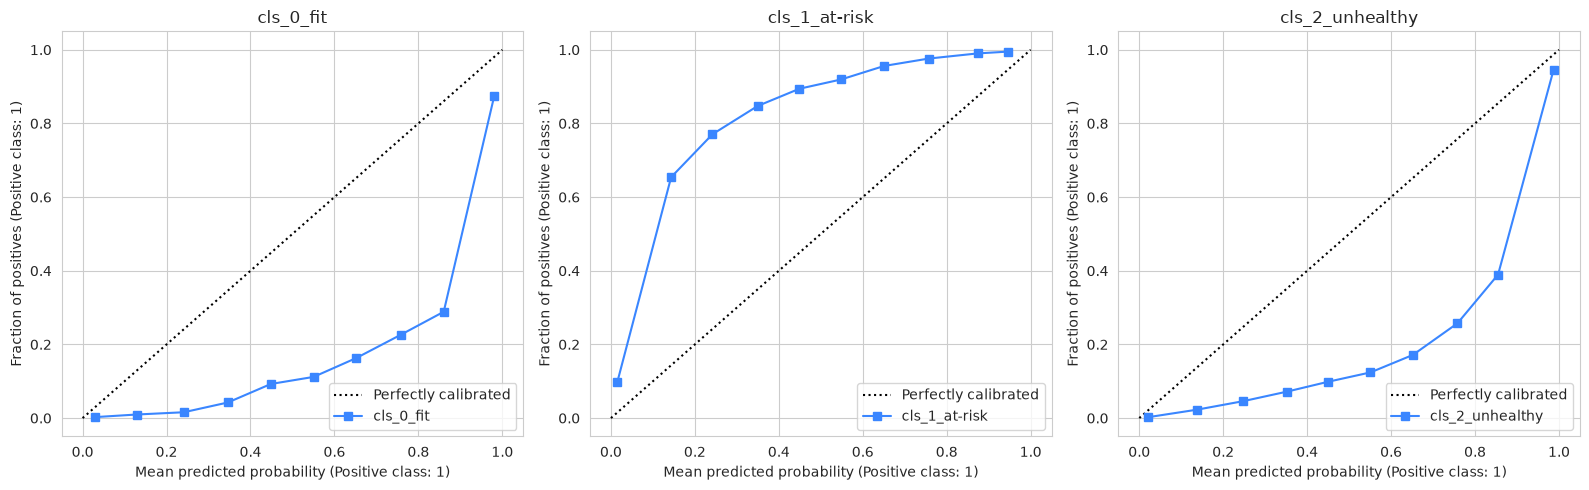

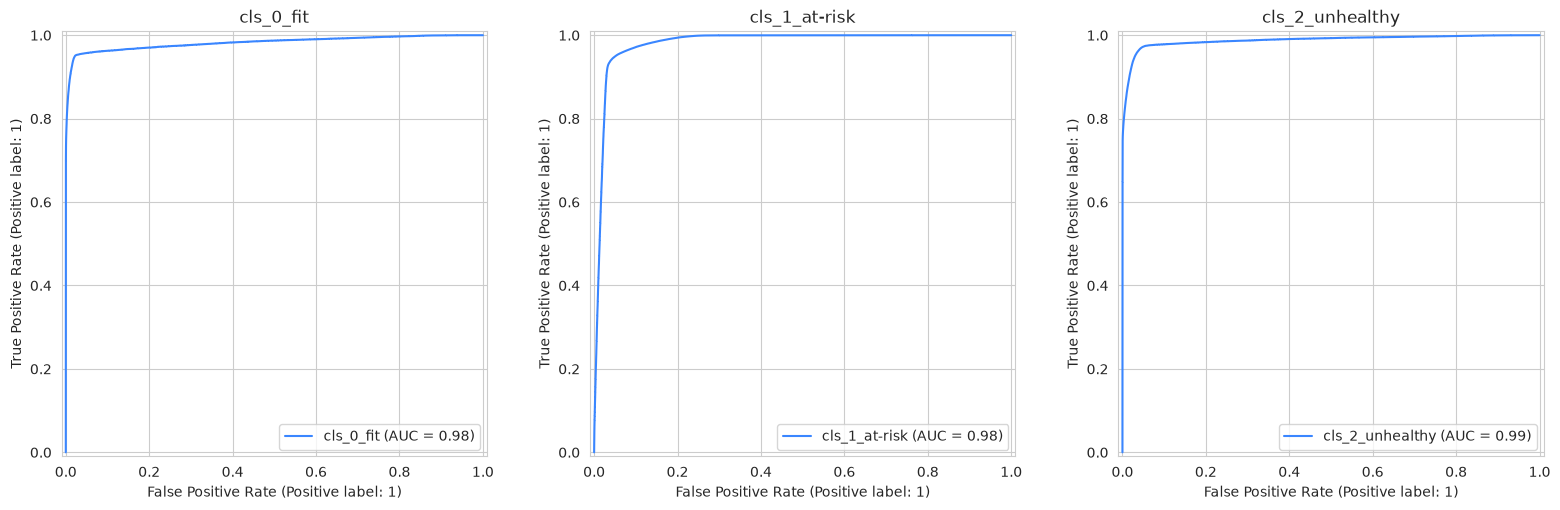


ydf_global_cart_94975 saved!


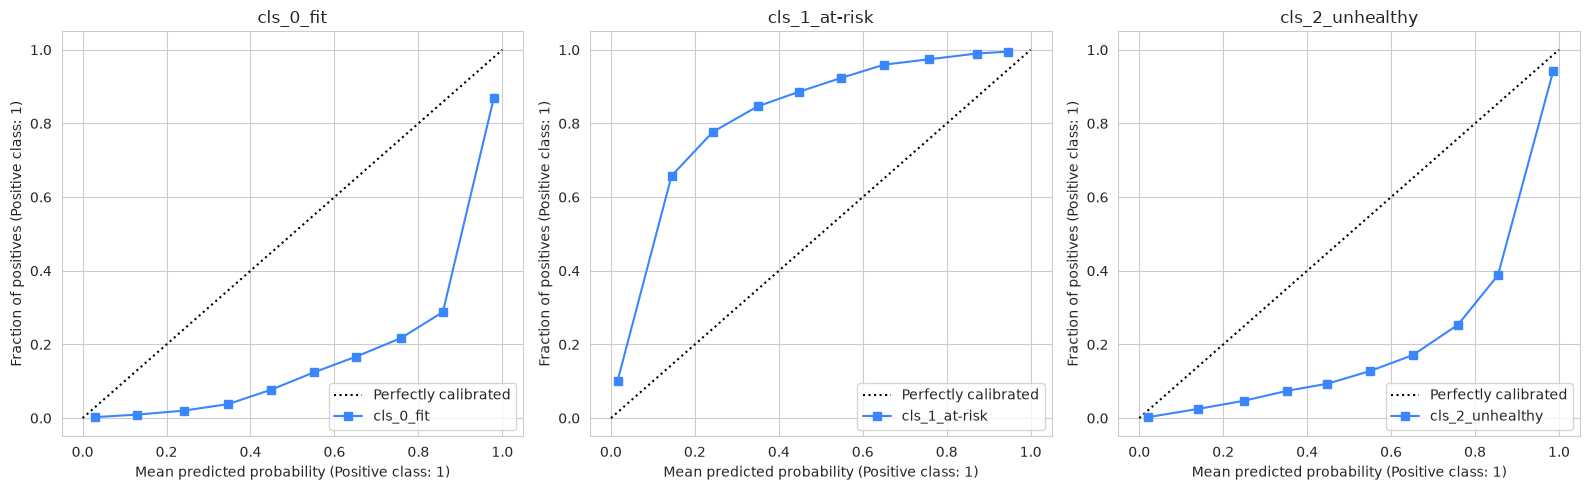

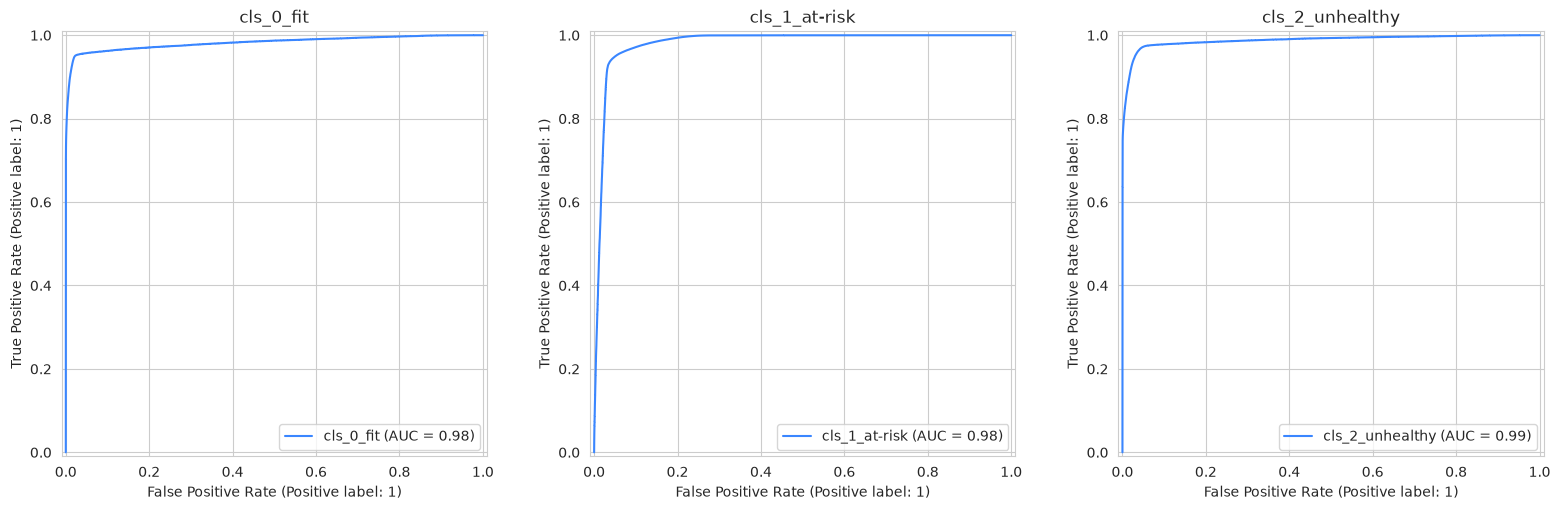


ydf_global_random_94954 saved!


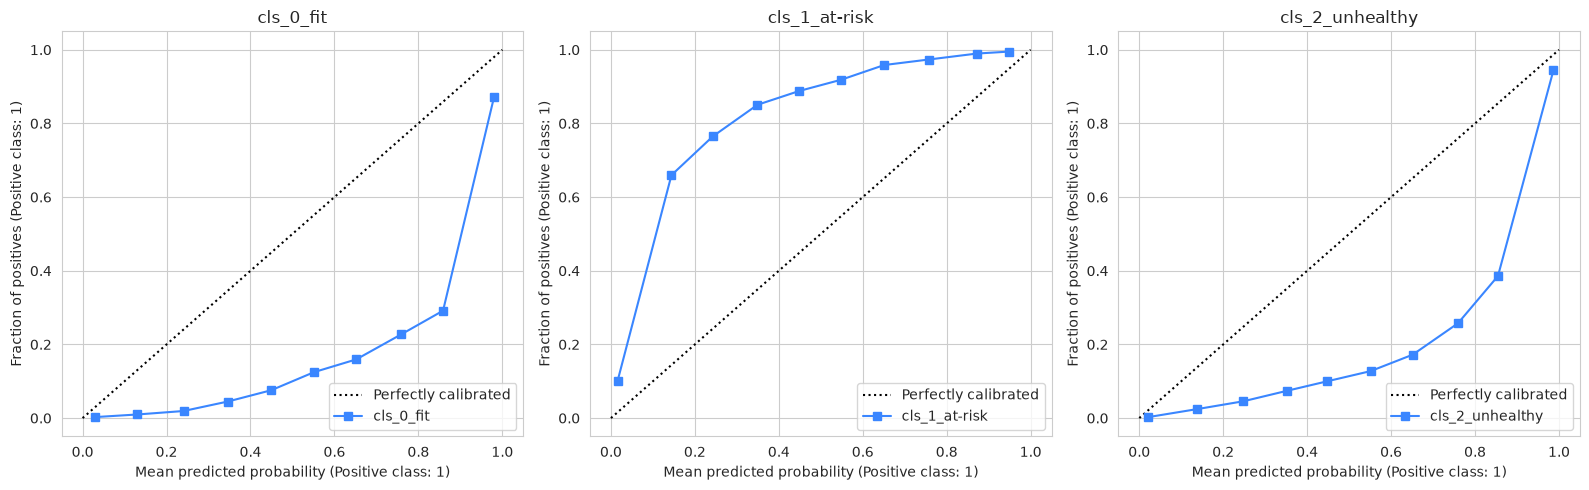

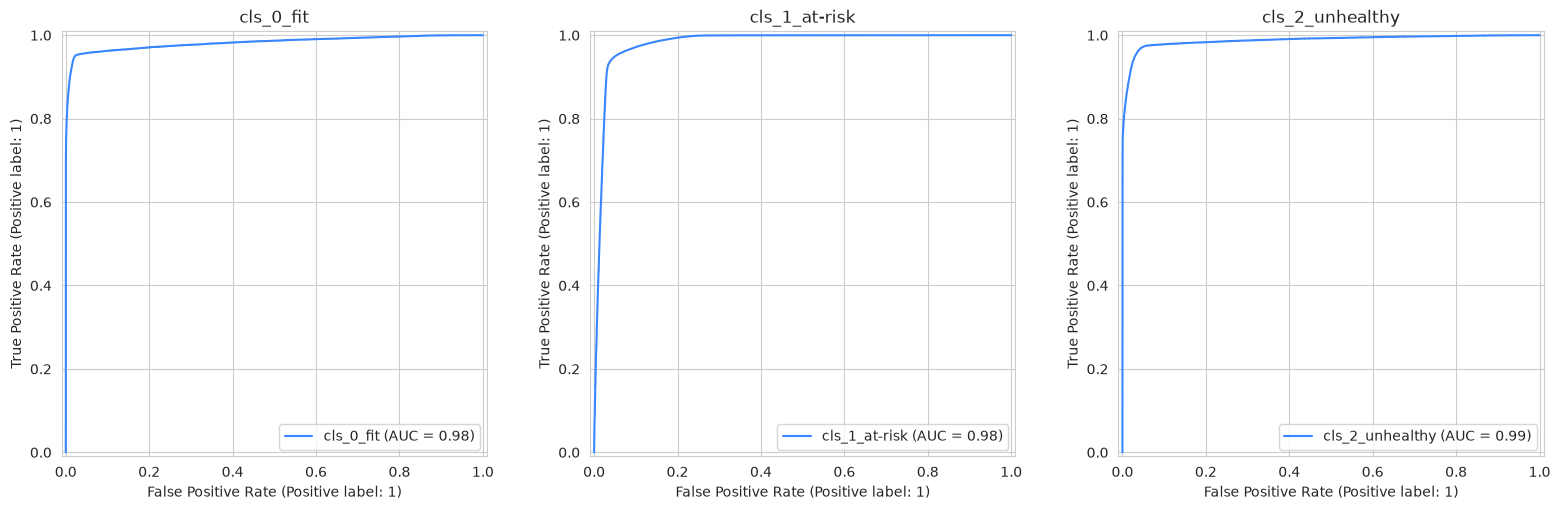

In [41]:
## -- Get oof predictions --
oof_predictions = []

for i, (k, v) in enumerate(all_predictions.items()):
    for x, y in v.items():
        if x == 'oof_preds':
            n = f"{k}_{str([*all_scores.values()][i]).split('.')[1]}"
            np.save(f"oof_{n}_.npy", y)
            print(f"{n} saved!")

            ## -- Plot oof distributions --
            y_labels = pd.Series(np.argmax(y, axis=1))
            classes = [*mapping.keys()]
            name0 = f"cls_0_{classes[0]}"
            name1 = f"cls_1_{classes[1]}"
            name2 = f"cls_2_{classes[2]}"

            y_cls_0 = (train_data[TARGET] == 0).astype(int)
            y_cls_1 = (train_data[TARGET] == 1).astype(int)
            y_cls_2 = (train_data[TARGET] == 2).astype(int)
            p_cls_0 = y[:, 0]
            p_cls_1 = y[:, 1]
            p_cls_2 = y[:, 2]

            _, axs = plt.subplots(1, 3, figsize=(16, 5))
            CalibrationDisplay.from_predictions(y_cls_0, p_cls_0, n_bins=10, name=name0, ax=axs[0])
            CalibrationDisplay.from_predictions(y_cls_1, p_cls_1, n_bins=10, name=name1, ax=axs[1])
            CalibrationDisplay.from_predictions(y_cls_2, p_cls_2, n_bins=10, name=name2, ax=axs[2])
            axs[0].set_title(name0)
            axs[1].set_title(name1)
            axs[2].set_title(name2)

            # plt.suptitle(n)
            plt.tight_layout()
            plt.show()

            _, axs = plt.subplots(1, 3, figsize=(16, 5))
            RocCurveDisplay.from_predictions(
                y_cls_0, p_cls_0, name=name0, ax=axs[0],
                sample_weight=get_sample_weights(y_cls_0, y_cls_0),
            )
            RocCurveDisplay.from_predictions(
                y_cls_1, p_cls_1, name=name1, ax=axs[1],
                sample_weight=get_sample_weights(y_cls_1, y_cls_1),
            )
            RocCurveDisplay.from_predictions(
                y_cls_2, p_cls_2, name=name2, ax=axs[2],
                sample_weight=get_sample_weights(y_cls_2, y_cls_2),
            )
            axs[0].set_title(name0)
            axs[1].set_title(name1)
            axs[2].set_title(name2)

            # plt.suptitle(n)
            plt.tight_layout()
            plt.show()

            print()

ydf_local_cart_94985 saved! (295753, 3)


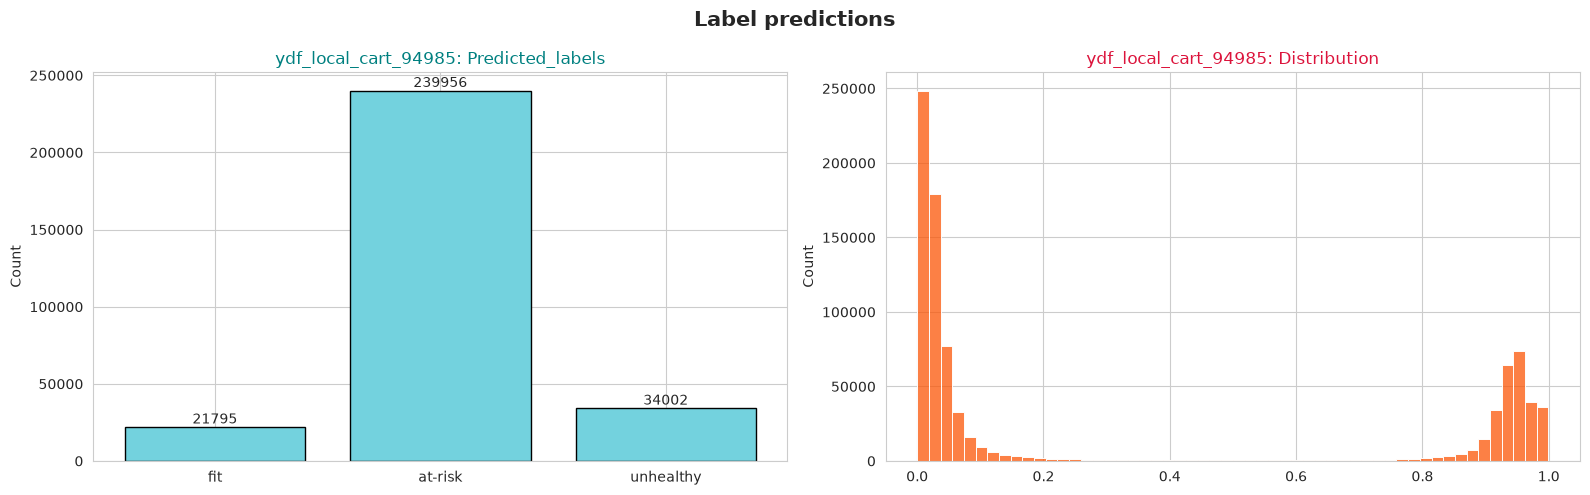


ydf_local_random_94969 saved! (295753, 3)


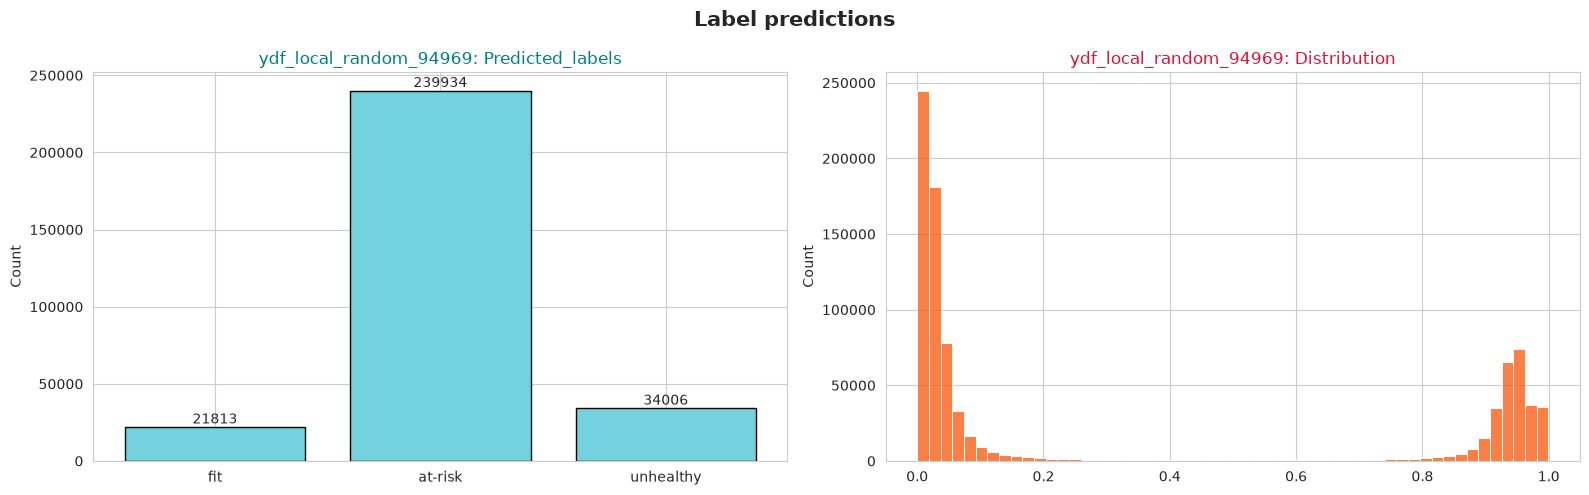


ydf_global_cart_94975 saved! (295753, 3)


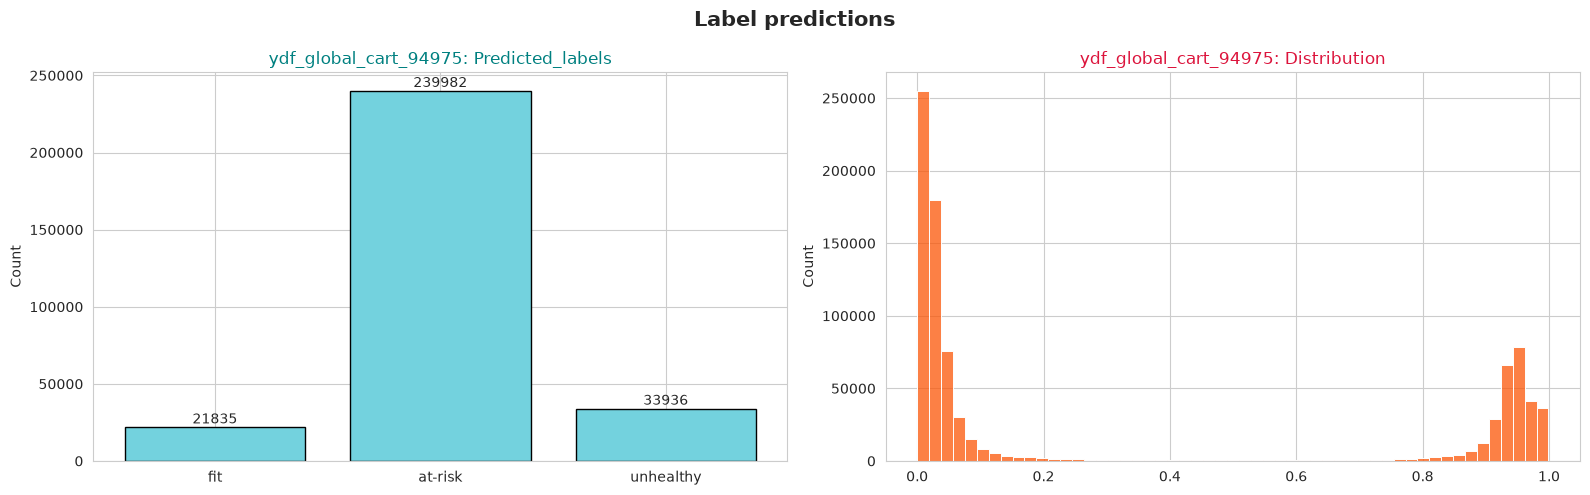


ydf_global_random_94954 saved! (295753, 3)


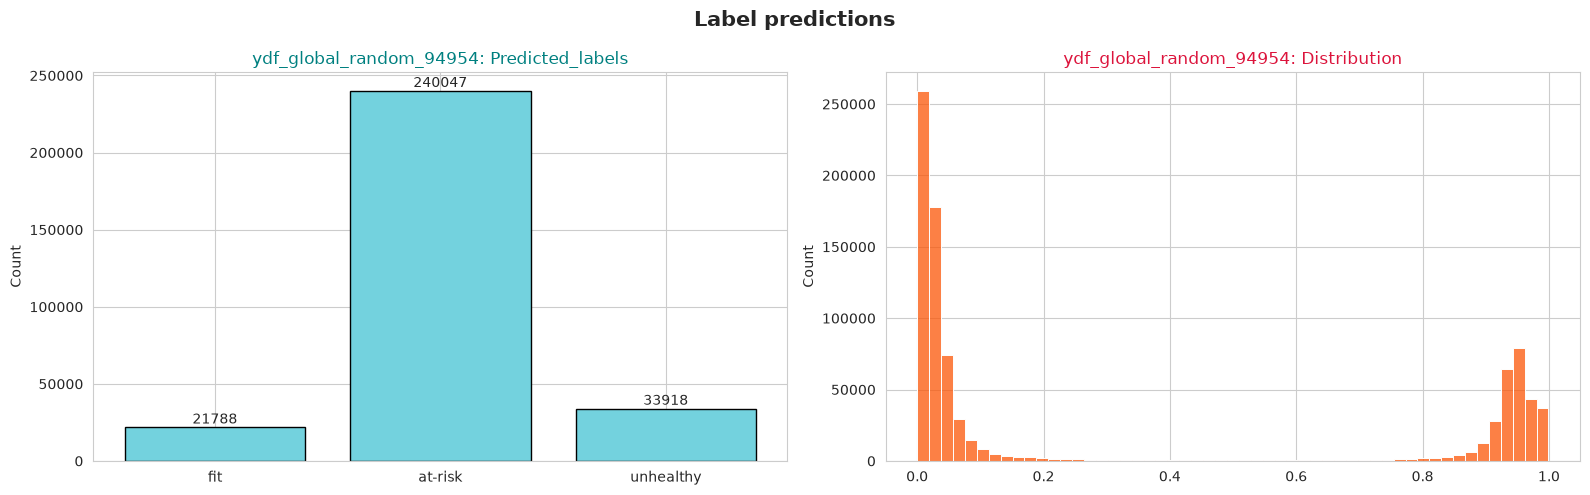

In [42]:
## -- Save TEST predictions/submissions --
model_results = {}

for i, (k, v) in enumerate(all_predictions.items()):
    for j, (x, y) in enumerate(v.items()):
        if x == 'test_preds':
            n = f"{k}_{str([*all_scores.values()][i]).split('.')[1]}"
            np.save(f"test_{n}_.npy", y)

            y_labels = np.argmax(y, axis=1)

            model_results[n] = pd.Series(y_labels).map(r_mapping)

            submit[TARGET] = pd.Series(y_labels).map(r_mapping)
            submit.to_csv(f'submit_base_{n}.csv', index=False)
            print(f'{n} saved! {y.shape}')

            fig, axs = plt.subplots(1, 2, figsize=(16, 5))

            counts = [np.sum(y_labels == _) for _ in range(len(np.unique(y_labels)))]
            axs[0].bar([*mapping.keys()], counts, color='#73D2DE', edgecolor='k')
            axs[0].set_title(f"{n}: Predicted_labels", color='teal')
            axs[0].set_ylabel('Count')

            for i, c in enumerate(counts):
                axs[0].text(i, c+2500, str(c), ha='center', fontsize=10)

            sns.histplot(y.ravel(), ax=axs[1], color='#FB5607')
            axs[1].set_title(f"{n}: Distribution", color='crimson')
            
            plt.suptitle('Label predictions', fontsize=15, fontweight='semibold')
            
            plt.tight_layout()
            plt.show()

            print()

In [43]:
pd.DataFrame(model_results)

,ydf_local_cart_94985,ydf_local_random_94969,ydf_global_cart_94975,ydf_global_random_94954
0,unhealthy,unhealthy,unhealthy,unhealthy
1,unhealthy,unhealthy,unhealthy,unhealthy
2,at-risk,at-risk,at-risk,at-risk
3,at-risk,at-risk,at-risk,at-risk
4,unhealthy,unhealthy,unhealthy,unhealthy
...,...,...,...,...
295748,fit,fit,fit,fit
295749,at-risk,at-risk,at-risk,at-risk
295750,unhealthy,unhealthy,unhealthy,unhealthy
295751,at-risk,at-risk,at-risk,at-risk


In [44]:
# try:
#     import shap
# except:
#     %pip install -q -U shap
#     import shap

# print(f"Shap version: {shap.__version__}")

In [45]:
# ## -- SHAP values: Feature Importances--
# knn_uni = all_predictions[list(all_predictions.keys())[0]]
# mlp_ann = all_predictions[list(all_predictions.keys())[-1]]
# max_display = 20

# for i, m in enumerate([knn_uni, mlp_ann]):
#     model = m['model']
#     x_train = m['data'][0]
#     x_train = m['data'][1]

#     ## -- Shap Explainer --
#     def f(x):
#         return model.predict_proba(x)[:, 1]

#     x_med = x_train.median().values.reshape((1, x_train.shape[1]))
#     explainer = shap.Explainer(f, x_med)
#     explanation = explainer(x_valid.iloc[:1000])

#     ## -- Bar plot --
#     plt.subplot(121)
#     shap.plots.bar(explanation[0], max_display=max_display, show=False)
#     plt.title('Bar - Overall impact on model predictions')
    
#     ## -- Beeswarm plot --
#     plt.subplot(122)
#     shap.plots.beeswarm(explanation, order=explanation.abs.max(0), plot_size=(18, 8),
#                         max_display=max_display, color_bar=False, show=False)
#     plt.title('Beeswarm - Most impactful features')

#     if i == 0:
#         plt.suptitle(list(all_predictions.keys())[i], fontweight='semibold')
#     else:
#         plt.suptitle(list(all_predictions.keys())[-1], fontweight='semibold')

#     plt.tight_layout(pad=1.5)
#     plt.show()
#     print()

In [46]:
## -- Inspect model --
all_data   = []
all_models = []

for k, v in all_predictions.items():
    for x, y in v.items():
        if x == 'data':
            all_data.append(y)
        elif x == 'model':
            all_models.append(y)

print(f"⚙️ Inspecting first YDF model...\n")
all_models[0].analyze(all_data[0])

⚙️ Inspecting first YDF model...

